
========== Assassin ==========
Shape: (5808, 8)
Label
Safe (0)     4091
Phish (1)    1717
Name: count, dtype: int64 

=== Test Evaluation (Standard NB) ===
Accuracy:          0.970
Balanced Accuracy: 0.963

                    precision    recall  f1-score   support

    Safe Email (0)       0.98      0.98      0.98       818
Phishing Email (1)       0.95      0.94      0.95       344

          accuracy                           0.97      1162
         macro avg       0.96      0.96      0.96      1162
      weighted avg       0.97      0.97      0.97      1162



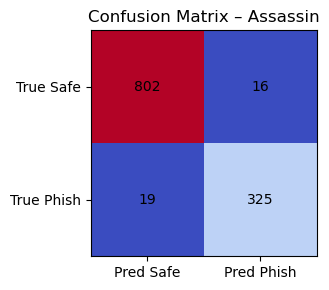

=== 5-fold CV (Balanced Accuracy) ===
Fold scores: [0.96  0.967 0.958 0.965 0.973]
Mean Balanced Accuracy: 0.964

========== Enron ==========
Shape: (29767, 4)
Label
Safe (0)     15791
Phish (1)    13976
Name: count, dtype: int64 

=== Test Evaluation (Standard NB) ===
Accuracy:          0.972
Balanced Accuracy: 0.972

                    precision    recall  f1-score   support

    Safe Email (0)       0.97      0.98      0.97      3159
Phishing Email (1)       0.97      0.97      0.97      2795

          accuracy                           0.97      5954
         macro avg       0.97      0.97      0.97      5954
      weighted avg       0.97      0.97      0.97      5954



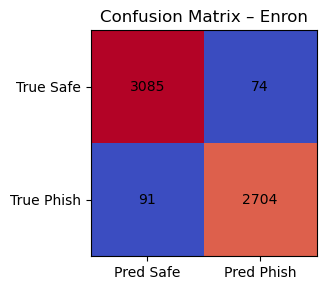

=== 5-fold CV (Balanced Accuracy) ===
Fold scores: [0.976 0.974 0.97  0.971 0.977]
Mean Balanced Accuracy: 0.974

========== Ling ==========
Shape: (2859, 4)
Label
Safe (0)     2401
Phish (1)     458
Name: count, dtype: int64 

=== Test Evaluation (Standard NB) ===
Accuracy:          0.993
Balanced Accuracy: 0.983

                    precision    recall  f1-score   support

    Safe Email (0)       0.99      1.00      1.00       480
Phishing Email (1)       0.99      0.97      0.98        92

          accuracy                           0.99       572
         macro avg       0.99      0.98      0.99       572
      weighted avg       0.99      0.99      0.99       572



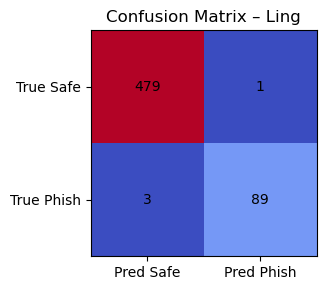

=== 5-fold CV (Balanced Accuracy) ===
Fold scores: [0.973 0.989 0.967 0.962 0.998]
Mean Balanced Accuracy: 0.978

========== CEAS-08 ==========
Shape: (39154, 8)
Label
Phish (1)    21842
Safe (0)     17312
Name: count, dtype: int64 

=== Test Evaluation (Standard NB) ===
Accuracy:          0.977
Balanced Accuracy: 0.979

                    precision    recall  f1-score   support

    Safe Email (0)       0.96      0.99      0.97      3462
Phishing Email (1)       1.00      0.96      0.98      4369

          accuracy                           0.98      7831
         macro avg       0.98      0.98      0.98      7831
      weighted avg       0.98      0.98      0.98      7831



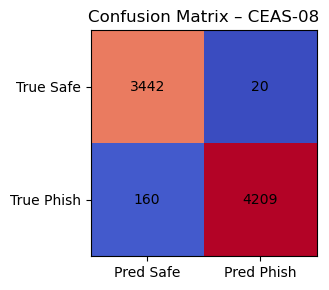

=== 5-fold CV (Balanced Accuracy) ===
Fold scores: [0.981 0.984 0.976 0.983 0.98 ]
Mean Balanced Accuracy: 0.981

========== TREC-05 ==========
⚠ Parsing issue in TREC-05, switching to python engine and skipping bad lines...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

from pandas.errors import ParserError
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 0) Define your datasets (relative to this notebook)
# -------------------------------------------------------------------
BASE = Path.cwd()              # current working directory
DATASET_DIR = BASE / "Dataset" # folder that holds your CSVs

dataset_files = {
    "Assassin": DATASET_DIR / "Assassin.csv",
    "Enron": DATASET_DIR / "Enron.csv",
    "Ling": DATASET_DIR / "Ling.csv",
    "CEAS-08": DATASET_DIR / "CEAS-08.csv",
    "TREC-05": DATASET_DIR / "TREC-05.csv",
    "TREC-06": DATASET_DIR / "TREC-06.csv",
    "TREC-07": DATASET_DIR / "TREC-07.csv",
}

results_summary = []


def run_balanced_nb(name: str, filepath: Path):
    print(f"\n========== {name} ==========")

    # --- Load dataset with robust CSV handling ---
    try:
        df = pd.read_csv(filepath)
    except ParserError:
        print(f"⚠ Parsing issue in {name}, switching to python engine and skipping bad lines...")
        df = pd.read_csv(
            filepath,
            engine="python",
            on_bad_lines="skip"  # skip malformed/broken lines
        )

    # Your files use: 'body' for text, 'label' for class (0/1)
    df = df.dropna(subset=["body"]).copy()
    df["Label"] = df["label"].astype(int)

    print("Shape:", df.shape)
    print(df["Label"].value_counts().rename(index={0: "Safe (0)", 1: "Phish (1)"}), "\n")

    X = df["body"].values
    y = df["Label"].values

    # ------------------------------------------------------
    # 1) Train/test split (stratified to keep class ratio)
    # ------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ------------------------------------------------------
    # 2) TF-IDF vectorization
    # ------------------------------------------------------
    tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train_t = tfidf.fit_transform(X_train)
    X_test_t = tfidf.transform(X_test)

    # ------------------------------------------------------
    # 3) Standard Multinomial Naive Bayes
    # ------------------------------------------------------
    nb = MultinomialNB()
    nb.fit(X_train_t, y_train)
    y_pred = nb.predict(X_test_t)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)

    print("=== Test Evaluation (Standard NB) ===")
    print(f"Accuracy:          {acc:.3f}")
    print(f"Balanced Accuracy: {bacc:.3f}\n")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Safe Email (0)", "Phishing Email (1)"],
        )
    )

    # ------------------------------------------------------
    # 4) Confusion matrix (per dataset)
    # ------------------------------------------------------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(3.4, 3))
    plt.imshow(cm, cmap="coolwarm")
    plt.title(f"Confusion Matrix – {name}")
    plt.xticks([0, 1], ["Pred Safe", "Pred Phish"])
    plt.yticks([0, 1], ["True Safe", "True Phish"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # 5) 5-fold cross-validation with balanced accuracy
    # ------------------------------------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_all = tfidf.fit_transform(X)  # TF-IDF on all samples for CV
    nb_cv = MultinomialNB()
    bacc_cv = cross_val_score(nb_cv, X_all, y, cv=cv, scoring="balanced_accuracy")

    print("=== 5-fold CV (Balanced Accuracy) ===")
    print("Fold scores:", np.round(bacc_cv, 3))
    print("Mean Balanced Accuracy:", np.round(bacc_cv.mean(), 3))

    # ------------------------------------------------------
    # 6) Store summary for comparison across sets
    # ------------------------------------------------------
    results_summary.append(
        {
            "Dataset": name,
            "Test Accuracy": acc,
            "Test Balanced Accuracy": bacc,
            "CV Balanced Accuracy Mean": bacc_cv.mean(),
        }
    )


# -------------------------------------------------------------------
# Run on all datasets
# -------------------------------------------------------------------
for name, path in dataset_files.items():
    run_balanced_nb(name, path)

print("\n\n===== Overall Comparison =====")
comp_df = pd.DataFrame(results_summary)
print(comp_df)


In [10]:
from pathlib import Path
import pandas as pd

DATASET_DIR = Path.cwd() / "Dataset"

for name, filename in {
    "Assassin": "Assassin.csv",
    "Enron": "Enron.csv",
    "Ling": "Ling.csv",
    "CEAS-08": "CEAS-08.csv",
    "TREC-05": "TREC-05.csv",
    "TREC-06": "TREC-06.csv",
    "TREC-07": "TREC-07.csv",
}.items():
    
    print(f"\n=== {name} ===")
    df = pd.read_csv(DATASET_DIR / filename, nrows=3)
    print(df.columns.tolist())
    print(df.head(1))



=== Assassin ===
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
                           sender  \
0  Robert Elz <kre@munnari.OZ.AU>   

                                            receiver  \
0  Chris Garrigues <cwg-dated-1030377287.06fa6d@D...   

                              date                   subject  \
0  Thu, 22 Aug 2002 18:26:25 +0700  Re: New Sequences Window   

                                                body  label  urls  
0  Date:        Wed, 21 Aug 2002 10:54:46 -0500  ...      0     1  

=== Enron ===
['subject', 'body', 'label']
                     subject  \
0  hpl nom for may 25 , 2001   

                                                body  label  
0  ( see attached file : hplno 525 . xls )\n- hpl...      0  

=== Ling ===
['subject', 'body', 'label']
                                   subject  \
0  job posting - apple-iss research center   

                                                body  label  
0  content - length : 3386 appl

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Penguin\\Documents\\School\\MachineLearning\\Project\\Dataset\\CEAS-08.cvs'